# 15 — Full Dataset vs. Subset Comparison

Compares the full-dataset champions (8461 proteins, `checkpoints/full_dataset_slim/`)
against the *same exact configs* trained on the subset (1045 proteins,
`checkpoints/phase_e/`) — identical round counts, `agg=multi`, and
embeddings/edges for both architectures. Dataset size is the only thing that
differs, so this isolates a real scale effect rather than comparing against a
different recipe.

| | Attention | Distance |
|---|---|---|
| Rounds (aa/aq/qq) | 4/2/16 | 8/2/24 |
| Full dataset (8461 proteins) | `full_dataset_slim/attention_aa4_aq2_qq16` | `full_dataset_slim/distance_aa8_aq2_qq24` |
| Subset (1045 proteins) | `phase_e/attention_aq2_qq16` | `phase_e/distance_aa8_aq2_qq24` |

**Updated 2026-09-21:** both sides were retrained since this notebook was first
run. Full-dataset champions migrated to the slim graph format
(`src/data/rbf.py`) and retrained at a uniform 75 epochs for both
architectures — previously 75 (attention) / 100 (distance), an epoch-budget
mismatch that confounded the cosine LR schedule's `T_max` between them. The
subset twins (`phase_e/*`) were found trained FP32 by accident and retrained
genuinely bf16, same manifest and legacy graph format as every sibling
`phase_a`–`h` checkpoint (see THESISPROCESSES.md "AQ+QQ Round Combination
Sweep"). Epoch budgets are now matched on the full-dataset side but still
differ from the subset side (75 vs. 120) — see §3.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("../..").resolve()))


## 1. Configuration

In [2]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"

RUNS = [
    dict(label="Attention — full dataset (8461 proteins)", model="attention", scale="full",
         ckpt_dir=CKPT_ROOT / "full_dataset_slim" / "attention_aa4_aq2_qq16", color="#2c7fb8"),
    dict(label="Attention — subset (1045 proteins, same config)", model="attention", scale="subset",
         ckpt_dir=CKPT_ROOT / "phase_e" / "attention_aq2_qq16", color="#a6cee3"),
    dict(label="Distance — full dataset (8461 proteins)", model="distance", scale="full",
         ckpt_dir=CKPT_ROOT / "full_dataset_slim" / "distance_aa8_aq2_qq24", color="#e6550d"),
    dict(label="Distance — subset (1045 proteins, same config)", model="distance", scale="subset",
         ckpt_dir=CKPT_ROOT / "phase_e" / "distance_aa8_aq2_qq24", color="#fdae6b"),
]

print(f"{'Run':<48}  {'Checkpoint dir':>6}  {'Metrics':>8}  {'Curves':>7}")
print("-" * 80)
for r in RUNS:
    has_ckpt    = r["ckpt_dir"].exists()
    has_metrics = (r["ckpt_dir"] / "test_metrics.json").exists()
    has_curves  = (r["ckpt_dir"] / "metrics.csv").exists()
    print(f"{r['label']:<48}  {'yes' if has_ckpt else 'no':>14}  "
          f"{'yes' if has_metrics else 'no':>8}  {'yes' if has_curves else 'no':>7}")


Run                                               Checkpoint dir   Metrics   Curves
--------------------------------------------------------------------------------
Attention — full dataset (8461 proteins)                     yes       yes      yes
Attention — subset (1045 proteins, same config)              yes       yes      yes
Distance — full dataset (8461 proteins)                      yes       yes      yes
Distance — subset (1045 proteins, same config)               yes       yes      yes


---
## 2. Global test metrics side by side


,run,scale,r,rmse,mae
0,Attention — full dataset (8461 proteins),full,0.934392,2.036752,1.497456
1,"Attention — subset (1045 proteins, same config)",subset,0.909014,2.251432,1.734746
2,Distance — full dataset (8461 proteins),full,0.938042,1.907914,1.398722
3,"Distance — subset (1045 proteins, same config)",subset,0.913916,2.074043,1.585884


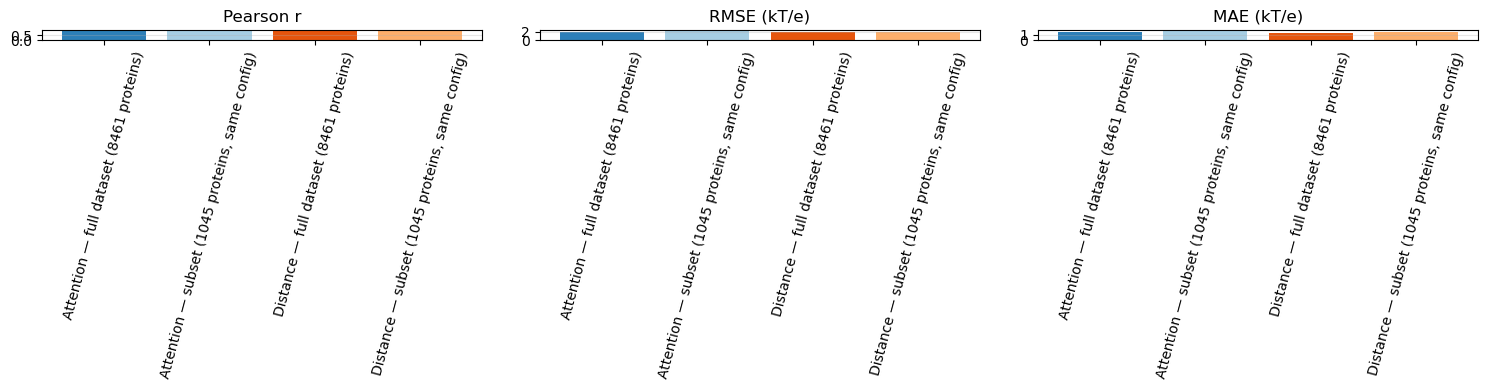

In [3]:
rows = []
for r in RUNS:
    mpath = r["ckpt_dir"] / "test_metrics.json"
    if not mpath.exists():
        rows.append({"run": r["label"], "scale": r["scale"], "r": None, "rmse": None, "mae": None})
        continue
    g = json.load(open(mpath))["global"]
    rows.append({"run": r["label"], "scale": r["scale"],
                 "r": g["pearson_r"], "rmse": g["rmse"], "mae": g["mae"]})

df = pd.DataFrame(rows)
display(df)

available = df.dropna(subset=["r"])
if len(available) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, col, title in zip(axes, ["r", "rmse", "mae"],
                               ["Pearson r", "RMSE (kT/e)", "MAE (kT/e)"]):
        colors = [r["color"] for r in RUNS if r["label"] in available["run"].values]
        ax.bar(available["run"], available[col], color=colors)
        ax.set_title(title)
        ax.tick_params(axis="x", rotation=75)
        ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("No test_metrics.json available yet for any run.")


---
## 3. Training curves overlay

Validation Pearson r vs. epoch. Both full-dataset champions now train for a
uniform 75 epochs (previously 75/100, mismatched); the subset baselines train
for 120 — x-axis is epoch number, not a normalized fraction of training, so
read accordingly.

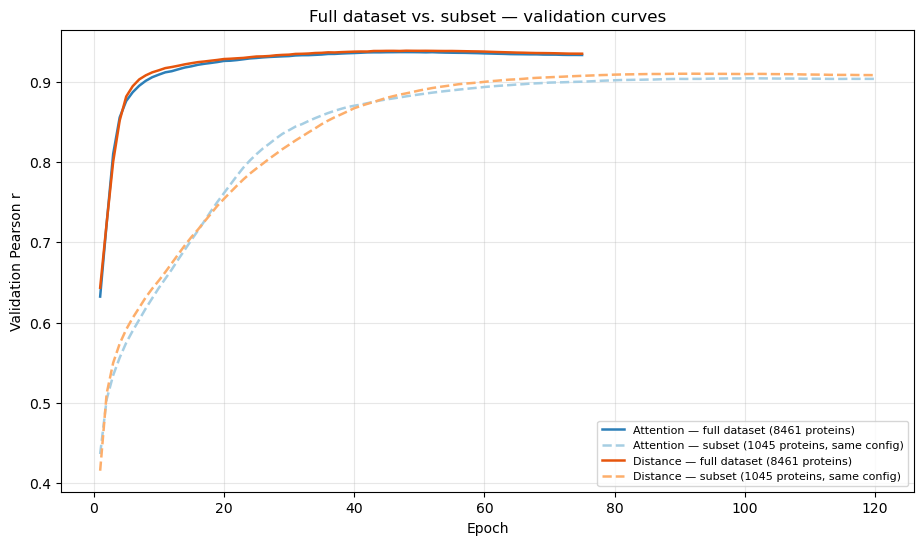

In [4]:
fig, ax = plt.subplots(figsize=(11, 6))
any_plotted = False
for r in RUNS:
    mpath = r["ckpt_dir"] / "metrics.csv"
    if not mpath.exists():
        continue
    hist = pd.read_csv(mpath)
    style = "-" if r["scale"] == "full" else "--"
    ax.plot(hist["epoch"], hist["val_pearson_r"], style, color=r["color"], label=r["label"], lw=1.8)
    any_plotted = True

if any_plotted:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation Pearson r")
    ax.set_title("Full dataset vs. subset — validation curves")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.show()
else:
    print("No metrics.csv available yet for any run.")


---
## 4. Per-protein ranking correlation

The full-dataset test split (848 proteins) and the subset test split (110 proteins)
are drawn from different overall pools with the same `split_seed=42` — their overlap
is small. Confirmed directly: **13 proteins** appear in both test splits. That's too
few to draw real conclusions from, but shown for completeness.

/home/student/miniconda3/envs/pyg_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Overlapping test proteins: 13


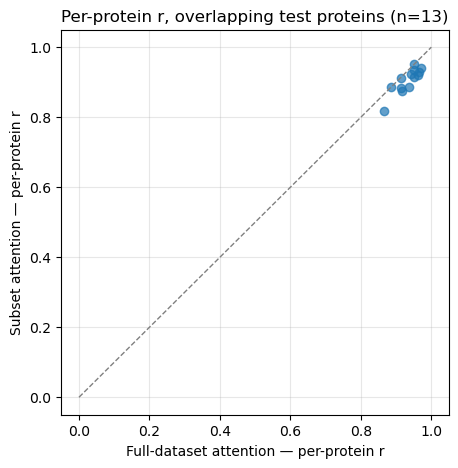

In [5]:
from src.data.dataset import load_split_manifest

_, _, full_test_ids   = load_split_manifest(THESIS_ROOT / "full_protein_dataset")
_, _, subset_test_ids = load_split_manifest(THESIS_ROOT / "subset_protein_data")
overlap_ids = sorted(set(full_test_ids) & set(subset_test_ids))
print(f"Overlapping test proteins: {len(overlap_ids)}")

def _per_protein_r(ckpt_dir, ids):
    mpath = ckpt_dir / "test_metrics.json"
    if not mpath.exists():
        return None
    pp = json.load(open(mpath))["per_protein"]
    return {pid: pp[pid]["pearson_r"] for pid in ids if pid in pp}

attn_full   = _per_protein_r(CKPT_ROOT / "full_dataset_slim" / "attention_aa4_aq2_qq16", overlap_ids)
attn_subset = _per_protein_r(CKPT_ROOT / "phase_e" / "attention_aq2_qq16", overlap_ids)

if attn_full and attn_subset and len(overlap_ids) >= 5:
    common = [pid for pid in overlap_ids if pid in attn_full and pid in attn_subset]
    x = [attn_full[pid] for pid in common]
    y = [attn_subset[pid] for pid in common]
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(x, y, alpha=0.7)
    ax.plot([0, 1], [0, 1], "--", color="gray", lw=1)
    ax.set_xlabel("Full-dataset attention — per-protein r")
    ax.set_ylabel("Subset attention — per-protein r")
    ax.set_title(f"Per-protein r, overlapping test proteins (n={len(common)})")
    ax.grid(alpha=0.3)
    plt.show()
else:
    print("Not enough overlapping data yet to plot (need both checkpoints' "
          "test_metrics.json and >=5 overlapping proteins).")


---
## 5. Decision

**Updated 2026-09-21** — both sides retrained (full-dataset: migrated to slim
graphs, uniform 75-epoch budget; subset: FP32 bug fixed, genuinely bf16 now).
See §1 note.

| | Full dataset | Subset (same config) | Δ |
|---|---|---|---|
| Attention r | 0.9344 | 0.9090 | +0.0254 |
| Distance r | 0.9380 | 0.9139 | +0.0241 |
| Attention RMSE | 2.0368 | 2.2514 | −0.2146 |
| Distance RMSE | 1.9079 | 2.0740 | −0.1661 |

**Reasoning:** with round counts and recipe now held fixed, the full-dataset
champions beat their subset twins by a consistent margin — roughly
+0.024–0.025 Pearson r and ~8–9% relative RMSE — for *both*
architectures. Because this comparison no longer confounds config with
dataset size (see §1), that gap is attributable to training-set scale
itself, not to the full-dataset runs happening to use a better round-count
config. Scale helps, by a similar amount regardless of architecture; neither
model looks closer to saturating on 8461 proteins than the other based on
this alone. The margin shifted slightly from what was previously recorded
(+0.0278/+0.0222 r for attention/distance) — attention's gap narrowed a
little (+0.0278 → +0.0254, from the full-dataset epoch-budget correction:
distance was 100 epochs before, now both are 75), while distance's widened
a little (+0.0222 → +0.0241, from its subset twin's FP32-bug fix pulling
that side's r down from 0.9164 to 0.9139). Neither shift is large enough to
change the finding — both architectures still gain a similar, real amount
from scale.